In [72]:
# pandas and numpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt, seaborn as sb

# plot
import matplotlib.pyplot as plt 

plt.rcParams.update({'figure.figsize':(9,7), 'figure.dpi':120})



from google.colab import files
uploaded = files.upload()

-----------------------------------------

import io

df = pd.read_csv(io.BytesIO(uploaded['machine_ID_3.csv']))

'''
df=df.drop(columns="datetime")
print(df.head())
print("\n")
print(df.isnull().sum())
print("\n")
print(df.info())
print("\n")
print(df.describe())
'''

# Read File

In [73]:
df = pd.read_csv("machine_ID_5.csv")

del df["Unnamed: 0"]


In [74]:
df.head()

,datetime,machineID,voltmean,rotatemean,pressuremean,vibrationmean,voltsd,rotatesd,pressuresd,vibrationsd,error1count,error2count,error3count,error4count,error5count,model,age,failure,time_diff
0,2015-01-02T05:00:00Z,5.0,175.674631,460.621226,97.928488,38.591031,14.915482,60.620670,10.824448,4.355144,0.0,0.0,0.0,0.0,0.0,model3,2.0,False,3.0
1,2015-01-02T08:00:00Z,5.0,174.725997,456.131987,97.732721,39.227595,15.527181,59.908203,10.349437,5.308114,0.0,0.0,0.0,0.0,0.0,model3,2.0,False,6.0
2,2015-01-02T11:00:00Z,5.0,175.639031,462.438271,99.929696,39.373528,17.261613,47.485082,9.914235,5.307678,0.0,0.0,0.0,0.0,0.0,model3,2.0,False,9.0
3,2015-01-02T14:00:00Z,5.0,174.371977,464.862486,101.786816,39.822974,15.876757,48.060236,10.515056,5.233337,0.0,0.0,0.0,0.0,0.0,model3,2.0,False,12.0
4,2015-01-02T17:00:00Z,5.0,172.739565,465.718196,100.475607,40.519679,17.050754,48.477629,10.391323,5.701510,0.0,0.0,0.0,0.0,0.0,model3,2.0,False,15.0


In [75]:
plotable = df.drop('age', axis=1)
plotable = df.drop('datetime', axis=1)
plotable = df.drop('time_diff', axis=1)


#plotable = df.drop('model', axis=1)
#plotable = df.drop('age', axis=1)
#plotable = df.drop('age', axis=1)


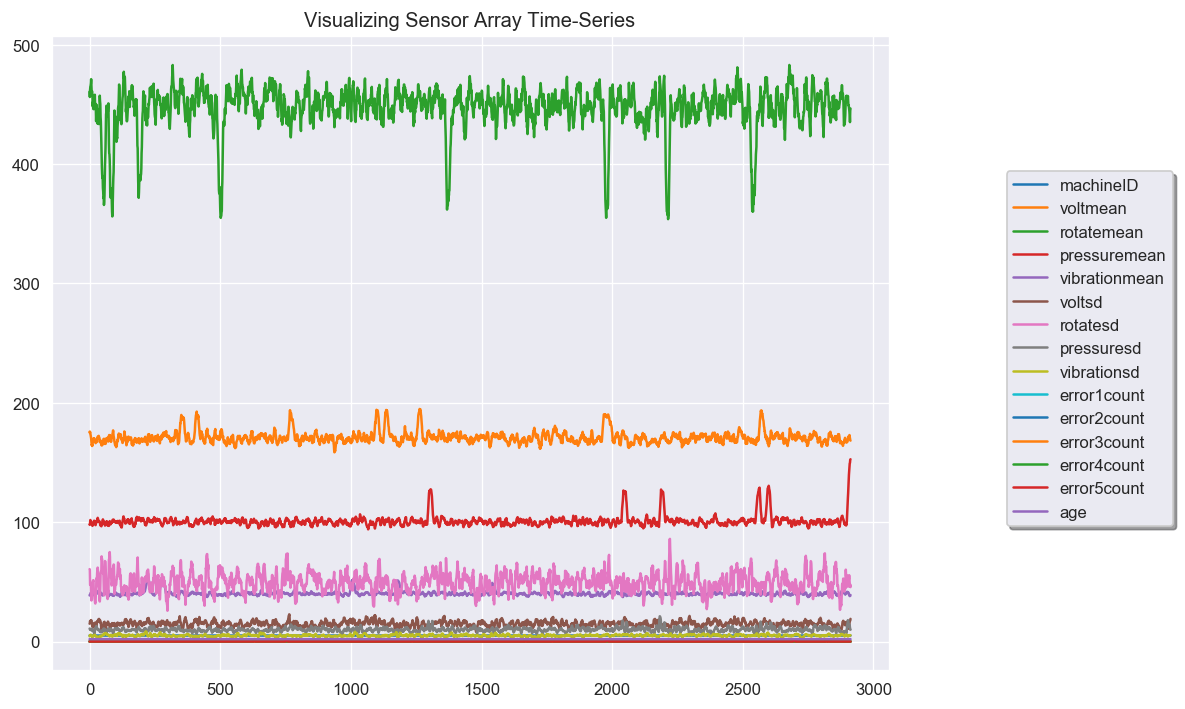

In [76]:
# Visualize the trends in data
sb.set_style('darkgrid')
plotable.plot(kind = 'line', legend = 'reverse', title = 'Visualizing Sensor Array Time-Series')
plt.legend(loc = 'upper right', shadow = True, bbox_to_anchor = (1.35, 0.8))
plt.show()

# Datetime Formatting

In [77]:
df['datetime'] = pd.to_datetime(df['datetime'],format='%Y-%m-%dT%H:%M')
df.dtypes

datetime         datetime64[ns, UTC]
machineID                    float64
voltmean                     float64
rotatemean                   float64
pressuremean                 float64
vibrationmean                float64
voltsd                       float64
rotatesd                     float64
pressuresd                   float64
vibrationsd                  float64
error1count                  float64
error2count                  float64
error3count                  float64
error4count                  float64
error5count                  float64
model                         object
age                          float64
failure                         bool
time_diff                    float64
dtype: object

In [78]:


df['year']=df['datetime'].dt.year 
df['month']=df['datetime'].dt.month 
df['day']=df['datetime'].dt.day

df['dayofweek_num']=df['datetime'].dt.dayofweek  
df['dayofweek_name']= df['datetime'].dt.day_name(locale = 'English') 



In [79]:
for col in df.columns: 
    print(col)

datetime
machineID
voltmean
rotatemean
pressuremean
vibrationmean
voltsd
rotatesd
pressuresd
vibrationsd
error1count
error2count
error3count
error4count
error5count
model
age
failure
time_diff
year
month
day
dayofweek_num
dayofweek_name


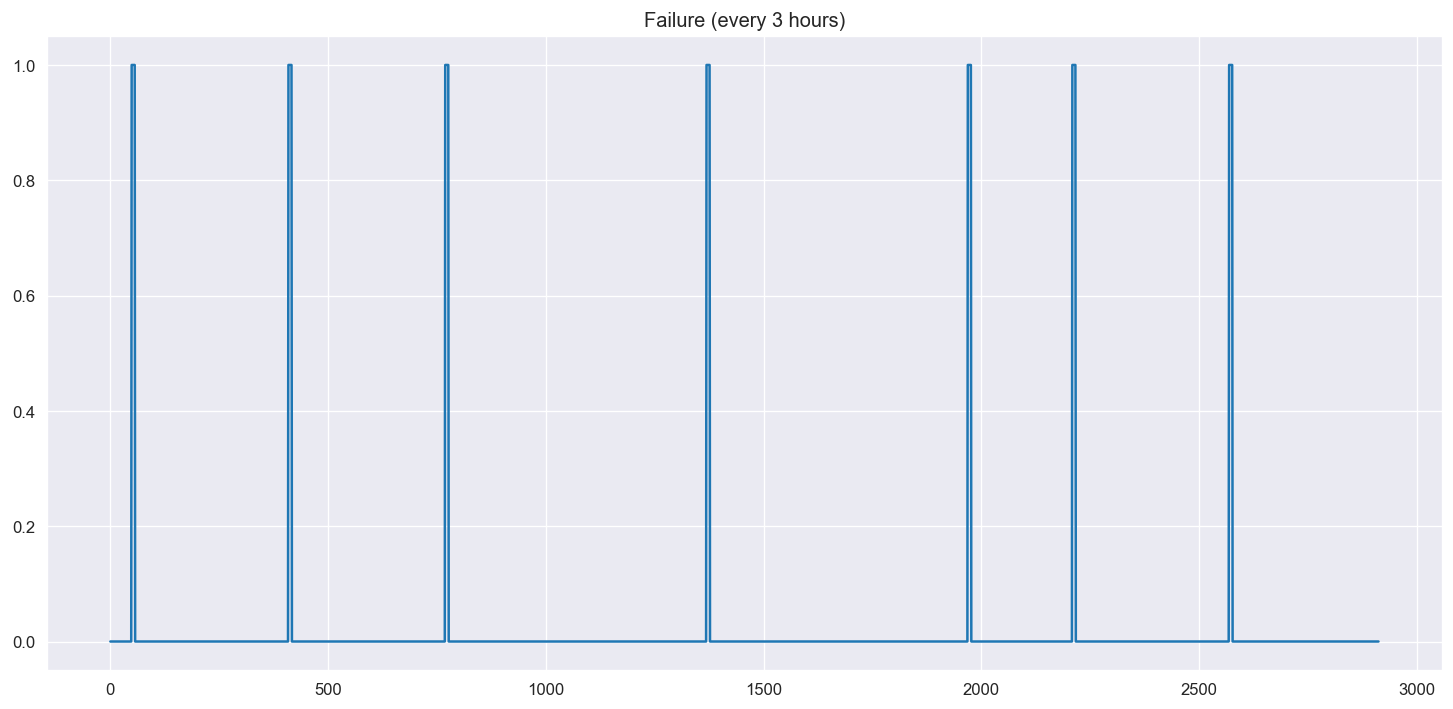

In [80]:
from pandas.plotting import register_matplotlib_converters

# required datetime converter for matplotlib plotting
register_matplotlib_converters()
plt.figure(figsize=(15, 7))
plt.plot(df['failure'])
plt.title('Failure (every 3 hours)')
plt.grid(True)
plt.show()

In [81]:
df.iloc[0:3,3:7]

,rotatemean,pressuremean,vibrationmean,voltsd
0,460.621226,97.928488,38.591031,14.915482
1,456.131987,97.732721,39.227595,15.527181
2,462.438271,99.929696,39.373528,17.261613


# Plot 

In [85]:
dataplot = pd.DataFrame(columns = ["time", "voltmean"])
dataplot['time'] = df['datetime']
dataplot['voltmean'] = df['voltsd']
dataplot['voltmean_lag'] = df['voltmean'].shift(1)
dataplot = dataplot.dropna()
dataplot

,time,voltmean,voltmean_lag
1,2015-01-02 08:00:00+00:00,15.527181,175.674631
2,2015-01-02 11:00:00+00:00,17.261613,174.725997
3,2015-01-02 14:00:00+00:00,15.876757,175.639031
4,2015-01-02 17:00:00+00:00,17.050754,174.371977
5,2015-01-02 20:00:00+00:00,16.675131,172.739565
...,...,...,...
2908,2015-12-31 17:00:00+00:00,14.975642,171.291885
2909,2015-12-31 20:00:00+00:00,16.512097,172.957293
2910,2015-12-31 23:00:00+00:00,17.262363,171.207999
2911,2016-01-01 02:00:00+00:00,17.596278,170.342656


In [86]:
import matplotlib
import matplotlib.pyplot as plt


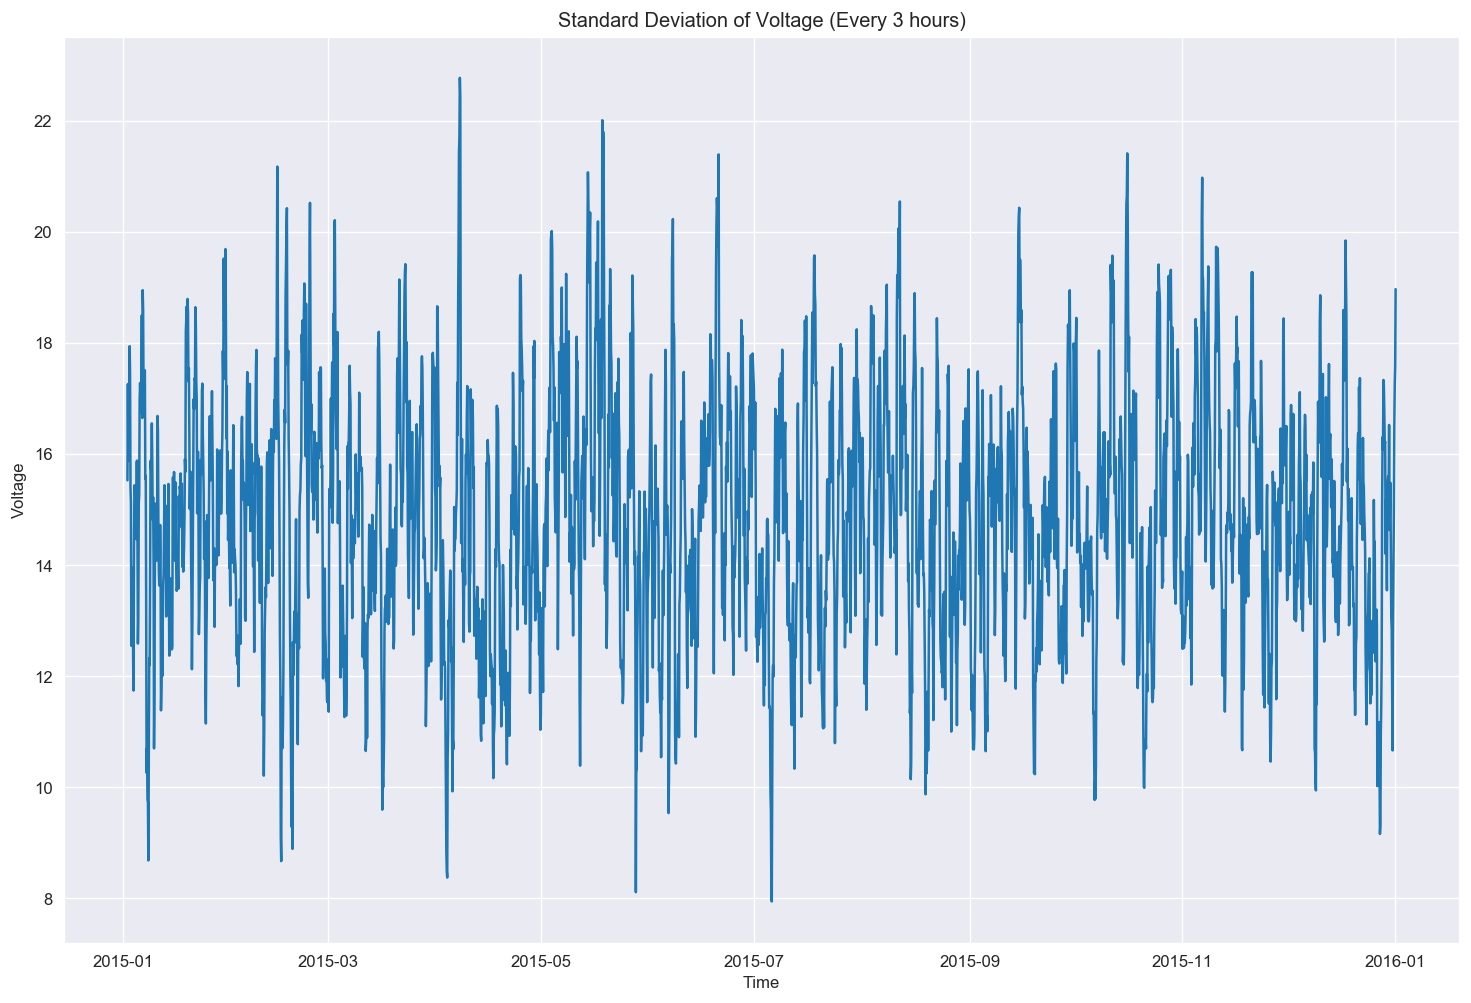

In [87]:
fig, ax = plt.subplots(figsize=(15,10))

ax.set_title('Standard Deviation of Voltage (Every 3 hours)')
ax.set_xlabel('Time')
ax.set_ylabel('Voltage')
ax.plot(dataplot['time'],dataplot['voltmean'])

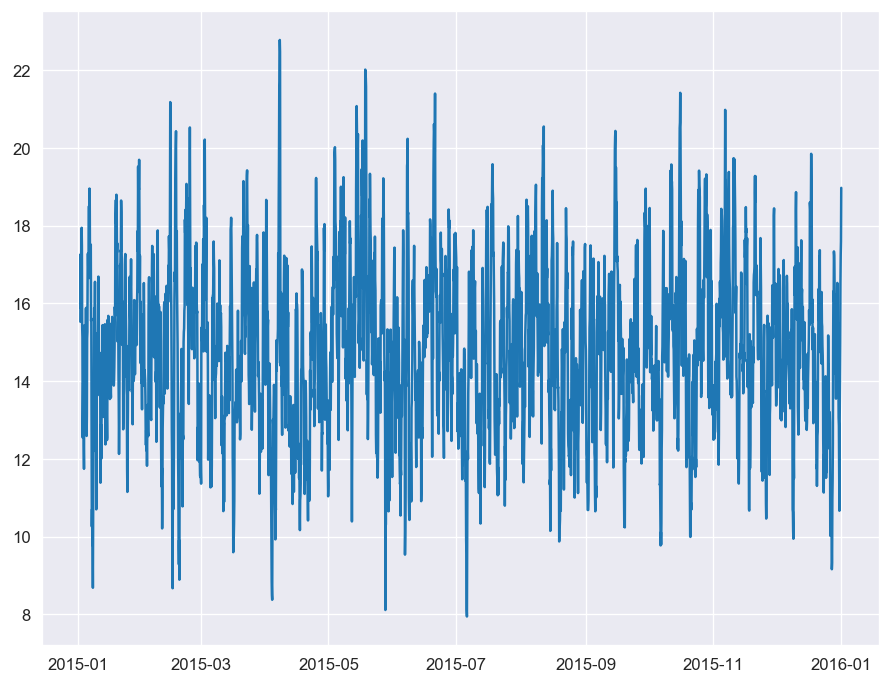

In [88]:
fig, bx = plt.subplots()
bx.plot(dataplot['time'],dataplot['voltmean'])

Text(0.5, 1.0, 'Lag Plot of Voltmean (Lag=1)')

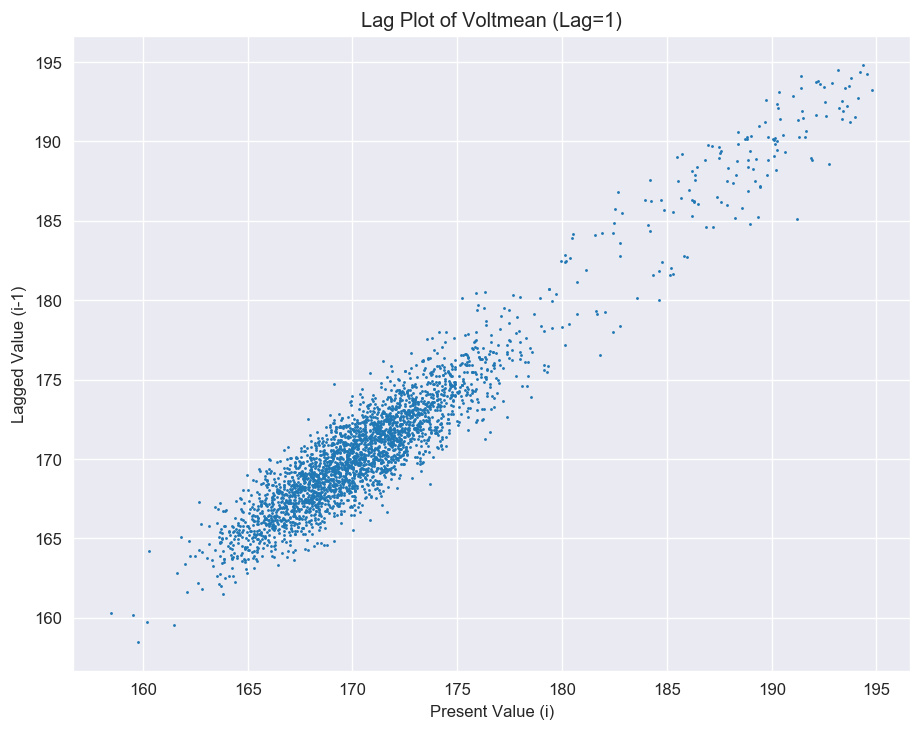

In [62]:

plt.scatter(dataplot['voltmean'],dataplot['voltmean_lag'], s=0.5)
plt.xlabel("Present Value (i)")
plt.ylabel("Lagged Value (i-1)")
plt.title("Lag Plot of Voltmean (Lag=1)")

In [66]:
df_lag = df

In [67]:
df_lag = df_lag.drop('machineID', axis = 1)
df_lag = df_lag.drop('model', axis = 1)
df_lag = df_lag.drop('error1count', axis = 1)
df_lag = df_lag.drop('error2count', axis = 1)
df_lag = df_lag.drop('error3count', axis = 1)
df_lag = df_lag.drop('error4count', axis = 1)
df_lag = df_lag.drop('error5count', axis = 1)
df_lag = df_lag.drop('age', axis = 1)


In [68]:
df_lag

,datetime,voltmean,rotatemean,pressuremean,vibrationmean,voltsd,rotatesd,pressuresd,vibrationsd,failure,time_diff,year,month,day,dayofweek_num,dayofweek_name
0,2015-01-02 05:00:00+00:00,175.674631,460.621226,97.928488,38.591031,14.915482,60.620670,10.824448,4.355144,False,3.0,2015,1,2,4,Friday
1,2015-01-02 08:00:00+00:00,174.725997,456.131987,97.732721,39.227595,15.527181,59.908203,10.349437,5.308114,False,6.0,2015,1,2,4,Friday
2,2015-01-02 11:00:00+00:00,175.639031,462.438271,99.929696,39.373528,17.261613,47.485082,9.914235,5.307678,False,9.0,2015,1,2,4,Friday
3,2015-01-02 14:00:00+00:00,174.371977,464.862486,101.786816,39.822974,15.876757,48.060236,10.515056,5.233337,False,12.0,2015,1,2,4,Friday
4,2015-01-02 17:00:00+00:00,172.739565,465.718196,100.475607,40.519679,17.050754,48.477629,10.391323,5.701510,False,15.0,2015,1,2,4,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2908,2015-12-31 17:00:00+00:00,172.957293,443.782574,146.266828,38.900233,14.975642,51.642884,14.282917,5.052672,False,8727.0,2015,12,31,3,Thursday
2909,2015-12-31 20:00:00+00:00,171.207999,441.079672,149.032272,38.044230,16.512097,48.456015,13.294827,5.342632,False,8730.0,2015,12,31,3,Thursday
2910,2015-12-31 23:00:00+00:00,170.342656,435.087822,149.766103,38.160252,17.262363,45.978899,11.652393,5.377855,False,8733.0,2015,12,31,3,Thursday
2911,2016-01-01 02:00:00+00:00,168.623160,444.723417,152.259884,38.227522,17.596278,47.770941,9.887812,5.344526,False,8736.0,2016,1,1,4,Friday


In [69]:
df_lag_plot = df_lag.drop('datetime', axis=1)
df_lag_plot1 = df_lag_plot.drop('time_diff', axis =1) 
df_lag_plot2 = df_lag_plot1.drop('dayofweek_num', axis =1) 
df_lag_plot3 = df_lag_plot2.drop('day', axis =1) 
df_lag_plot4 = df_lag_plot3.drop('month', axis =1) 
df_lag_plot5 = df_lag_plot4.drop('year', axis =1) 


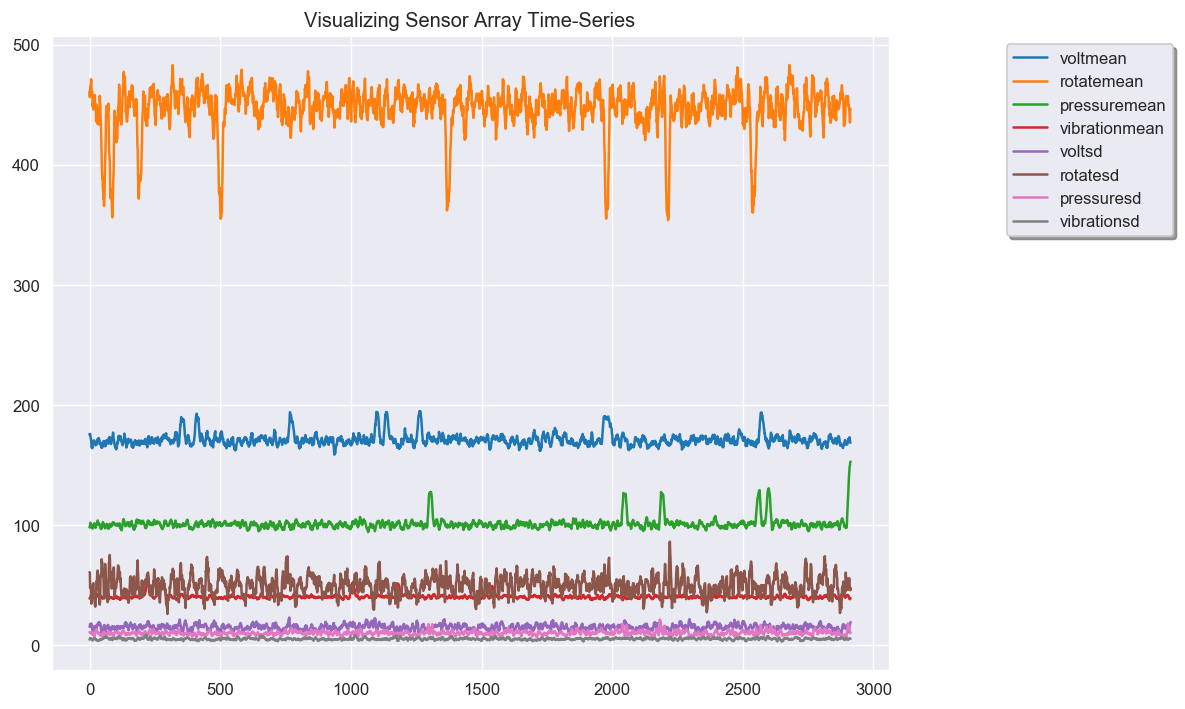

In [70]:
# Visualize the trends in data
sb.set_style('darkgrid')
df_lag_plot5.plot(kind = 'line', legend = 'reverse', title = 'Visualizing Sensor Array Time-Series')
plt.legend(loc = 'upper right', shadow = True, bbox_to_anchor = (1.35, 1))
plt.show()

In [18]:
pressuremean_lag = df_lag

In [19]:
pressuremean_lag = pressuremean_lag.drop('rotatemean', axis = 1)
pressuremean_lag = pressuremean_lag.drop('vibrationmean', axis = 1)
pressuremean_lag = pressuremean_lag.drop('voltmean', axis = 1)
pressuremean_lag = pressuremean_lag.drop('rotatesd', axis = 1)
pressuremean_lag = pressuremean_lag.drop('vibrationsd', axis = 1)
pressuremean_lag = pressuremean_lag.drop('voltsd', axis = 1)
pressuremean_lag = pressuremean_lag.drop('pressuresd', axis = 1)

In [20]:
pressuremean_lag 

,datetime,pressuremean,failure,time_diff,year,month,day,dayofweek_num,dayofweek_name
0,2015-01-02 05:00:00+00:00,97.928488,False,3.0,2015,1,2,4,Friday
1,2015-01-02 08:00:00+00:00,97.732721,False,6.0,2015,1,2,4,Friday
2,2015-01-02 11:00:00+00:00,99.929696,False,9.0,2015,1,2,4,Friday
3,2015-01-02 14:00:00+00:00,101.786816,False,12.0,2015,1,2,4,Friday
4,2015-01-02 17:00:00+00:00,100.475607,False,15.0,2015,1,2,4,Friday
...,...,...,...,...,...,...,...,...,...
2908,2015-12-31 17:00:00+00:00,146.266828,False,8727.0,2015,12,31,3,Thursday
2909,2015-12-31 20:00:00+00:00,149.032272,False,8730.0,2015,12,31,3,Thursday
2910,2015-12-31 23:00:00+00:00,149.766103,False,8733.0,2015,12,31,3,Thursday
2911,2016-01-01 02:00:00+00:00,152.259884,False,8736.0,2016,1,1,4,Friday


# LAG

In [21]:
for i in range(1, 5):
    pressuremean_lag['pressuremean_lag_{}'.format(i)] = pressuremean_lag['pressuremean'].shift(i)

In [22]:
pressuremean_lag

,datetime,pressuremean,failure,time_diff,year,month,day,dayofweek_num,dayofweek_name,pressuremean_lag_1,pressuremean_lag_2,pressuremean_lag_3,pressuremean_lag_4
0,2015-01-02 05:00:00+00:00,97.928488,False,3.0,2015,1,2,4,Friday,NaN,NaN,NaN,NaN
1,2015-01-02 08:00:00+00:00,97.732721,False,6.0,2015,1,2,4,Friday,97.928488,NaN,NaN,NaN
2,2015-01-02 11:00:00+00:00,99.929696,False,9.0,2015,1,2,4,Friday,97.732721,97.928488,NaN,NaN
3,2015-01-02 14:00:00+00:00,101.786816,False,12.0,2015,1,2,4,Friday,99.929696,97.732721,97.928488,NaN
4,2015-01-02 17:00:00+00:00,100.475607,False,15.0,2015,1,2,4,Friday,101.786816,99.929696,97.732721,97.928488
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2908,2015-12-31 17:00:00+00:00,146.266828,False,8727.0,2015,12,31,3,Thursday,142.911402,139.647908,135.521053,129.868899
2909,2015-12-31 20:00:00+00:00,149.032272,False,8730.0,2015,12,31,3,Thursday,146.266828,142.911402,139.647908,135.521053
2910,2015-12-31 23:00:00+00:00,149.766103,False,8733.0,2015,12,31,3,Thursday,149.032272,146.266828,142.911402,139.647908
2911,2016-01-01 02:00:00+00:00,152.259884,False,8736.0,2016,1,1,4,Friday,149.766103,149.032272,146.266828,142.911402


In [23]:
pressuremean_lag = pressuremean_lag.dropna()

In [24]:
label_col = pressuremean_lag.columns

In [25]:
label_col


Index(['datetime', 'pressuremean', 'failure', 'time_diff', 'year', 'month',
       'day', 'dayofweek_num', 'dayofweek_name', 'pressuremean_lag_1',
       'pressuremean_lag_2', 'pressuremean_lag_3', 'pressuremean_lag_4'],
      dtype='object')

In [26]:
lag_cols = [col for col in pressuremean_lag.columns if 'lag' in col]
pressuremean_lag['pressuremean_rolling_mean'] = pressuremean_lag[lag_cols].mean(axis=1)

C:\Users\User\anaconda3\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [27]:
lag_cols

['pressuremean_lag_1',
 'pressuremean_lag_2',
 'pressuremean_lag_3',
 'pressuremean_lag_4']

In [28]:
pressuremean_lag

,datetime,pressuremean,failure,time_diff,year,month,day,dayofweek_num,dayofweek_name,pressuremean_lag_1,pressuremean_lag_2,pressuremean_lag_3,pressuremean_lag_4,pressuremean_rolling_mean
4,2015-01-02 17:00:00+00:00,100.475607,False,15.0,2015,1,2,4,Friday,101.786816,99.929696,97.732721,97.928488,99.344430
5,2015-01-02 20:00:00+00:00,100.013669,False,18.0,2015,1,2,4,Friday,100.475607,101.786816,99.929696,97.732721,99.981210
6,2015-01-02 23:00:00+00:00,100.464625,False,21.0,2015,1,2,4,Friday,100.013669,100.475607,101.786816,99.929696,100.551447
7,2015-01-03 02:00:00+00:00,98.803557,False,24.0,2015,1,3,5,Saturday,100.464625,100.013669,100.475607,101.786816,100.685179
8,2015-01-03 05:00:00+00:00,99.068125,False,27.0,2015,1,3,5,Saturday,98.803557,100.464625,100.013669,100.475607,99.939364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2908,2015-12-31 17:00:00+00:00,146.266828,False,8727.0,2015,12,31,3,Thursday,142.911402,139.647908,135.521053,129.868899,136.987315
2909,2015-12-31 20:00:00+00:00,149.032272,False,8730.0,2015,12,31,3,Thursday,146.266828,142.911402,139.647908,135.521053,141.086798
2910,2015-12-31 23:00:00+00:00,149.766103,False,8733.0,2015,12,31,3,Thursday,149.032272,146.266828,142.911402,139.647908,144.464603
2911,2016-01-01 02:00:00+00:00,152.259884,False,8736.0,2016,1,1,4,Friday,149.766103,149.032272,146.266828,142.911402,146.994151


# x y

In [29]:
pressuremean_lag = pressuremean_lag.drop('time_diff', axis = 1)
pressuremean_lag = pressuremean_lag.drop('year', axis = 1)
pressuremean_lag = pressuremean_lag.drop('month', axis = 1)
pressuremean_lag = pressuremean_lag.drop('day', axis = 1)
pressuremean_lag = pressuremean_lag.drop('dayofweek_num', axis = 1)
pressuremean_lag = pressuremean_lag.drop('dayofweek_name', axis = 1)


In [30]:
pressuremean_lag

,datetime,pressuremean,failure,pressuremean_lag_1,pressuremean_lag_2,pressuremean_lag_3,pressuremean_lag_4,pressuremean_rolling_mean
4,2015-01-02 17:00:00+00:00,100.475607,False,101.786816,99.929696,97.732721,97.928488,99.344430
5,2015-01-02 20:00:00+00:00,100.013669,False,100.475607,101.786816,99.929696,97.732721,99.981210
6,2015-01-02 23:00:00+00:00,100.464625,False,100.013669,100.475607,101.786816,99.929696,100.551447
7,2015-01-03 02:00:00+00:00,98.803557,False,100.464625,100.013669,100.475607,101.786816,100.685179
8,2015-01-03 05:00:00+00:00,99.068125,False,98.803557,100.464625,100.013669,100.475607,99.939364
...,...,...,...,...,...,...,...,...
2908,2015-12-31 17:00:00+00:00,146.266828,False,142.911402,139.647908,135.521053,129.868899,136.987315
2909,2015-12-31 20:00:00+00:00,149.032272,False,146.266828,142.911402,139.647908,135.521053,141.086798
2910,2015-12-31 23:00:00+00:00,149.766103,False,149.032272,146.266828,142.911402,139.647908,144.464603
2911,2016-01-01 02:00:00+00:00,152.259884,False,149.766103,149.032272,146.266828,142.911402,146.994151


In [31]:
voltmean_lag = pd.DataFrame() 
voltmean_lag["voltmean"] = df["voltmean"]

for i in range(1, 5):
    voltmean_lag['voltmean_lag_{}'.format(i)] = voltmean_lag['voltmean'].shift(i)
    
voltmean_lag = voltmean_lag.dropna()

In [32]:
rotatemean_lag = pd.DataFrame() 
rotatemean_lag["rotatemean"] = df["rotatemean"]

for i in range(1, 5):
    rotatemean_lag['rotatemean_lag_{}'.format(i)] = rotatemean_lag['rotatemean'].shift(i)
    
rotatemean_lag = rotatemean_lag.dropna()

In [33]:
vibrationmean_lag = pd.DataFrame() 
vibrationmean_lag["vibrationmean"] = df["vibrationmean"]

for i in range(1, 5):
    vibrationmean_lag['vibrationmean_lag_{}'.format(i)] = vibrationmean_lag['vibrationmean'].shift(i)
    
vibrationmean_lag = vibrationmean_lag.dropna()

In [34]:
voltsd_lag = pd.DataFrame() 
voltsd_lag["voltsd"] = df["voltsd"]

for i in range(1, 5):
    voltsd_lag['voltsd_lag_{}'.format(i)] = voltsd_lag['voltsd'].shift(i)
    
voltsd_lag = voltsd_lag.dropna()

In [35]:
vibrationsd_lag = pd.DataFrame() 
vibrationsd_lag["vibrationsd"] = df["vibrationsd"]

for i in range(1, 5):
    vibrationsd_lag['vibrationsd_lag_{}'.format(i)] = vibrationsd_lag['vibrationsd'].shift(i)
    
vibrationsd_lag = vibrationsd_lag.dropna()

In [36]:
pressuresd_lag = pd.DataFrame() 
pressuresd_lag["pressuresd"] = df["pressuresd"]

for i in range(1, 5):
    pressuresd_lag['pressuresd_lag_{}'.format(i)] = pressuresd_lag['pressuresd'].shift(i)
    
pressuresd_lag = pressuresd_lag.dropna()

In [37]:
pressuresd_lag

,pressuresd,pressuresd_lag_1,pressuresd_lag_2,pressuresd_lag_3,pressuresd_lag_4
4,10.391323,10.515056,9.914235,10.349437,10.824448
5,9.510092,10.391323,10.515056,9.914235,10.349437
6,9.500981,9.510092,10.391323,10.515056,9.914235
7,10.487470,9.500981,9.510092,10.391323,10.515056
8,10.444890,10.487470,9.500981,9.510092,10.391323
...,...,...,...,...,...
2908,14.282917,13.320476,12.396338,12.859411,16.663880
2909,13.294827,14.282917,13.320476,12.396338,12.859411
2910,11.652393,13.294827,14.282917,13.320476,12.396338
2911,9.887812,11.652393,13.294827,14.282917,13.320476


In [38]:
rotatesd_lag = pd.DataFrame() 
rotatesd_lag["rotatesd"] = df["rotatesd"]

for i in range(1, 5):
    rotatesd_lag['rotatesd_lag_{}'.format(i)] = rotatesd_lag['rotatesd'].shift(i)
    
rotatesd_lag = rotatesd_lag.dropna()

In [39]:
rotatesd_lag

,rotatesd,rotatesd_lag_1,rotatesd_lag_2,rotatesd_lag_3,rotatesd_lag_4
4,48.477629,48.060236,47.485082,59.908203,60.620670
5,48.133591,48.477629,48.060236,47.485082,59.908203
6,39.138483,48.133591,48.477629,48.060236,47.485082
7,34.373740,39.138483,48.133591,48.477629,48.060236
8,44.603842,34.373740,39.138483,48.133591,48.477629
...,...,...,...,...,...
2908,51.642884,55.524544,52.098303,53.315883,50.847559
2909,48.456015,51.642884,55.524544,52.098303,53.315883
2910,45.978899,48.456015,51.642884,55.524544,52.098303
2911,47.770941,45.978899,48.456015,51.642884,55.524544


In [40]:
compliled_lag = pd.concat([pressuremean_lag, rotatesd_lag, pressuresd_lag, 
                           voltsd_lag, vibrationsd_lag, 
                           vibrationmean_lag, rotatemean_lag, 
                           voltmean_lag], axis=1)


In [41]:
compliled_lag

,datetime,pressuremean,failure,pressuremean_lag_1,pressuremean_lag_2,pressuremean_lag_3,pressuremean_lag_4,pressuremean_rolling_mean,rotatesd,rotatesd_lag_1,...,rotatemean,rotatemean_lag_1,rotatemean_lag_2,rotatemean_lag_3,rotatemean_lag_4,voltmean,voltmean_lag_1,voltmean_lag_2,voltmean_lag_3,voltmean_lag_4
4,2015-01-02 17:00:00+00:00,100.475607,False,101.786816,99.929696,97.732721,97.928488,99.344430,48.477629,48.060236,...,465.718196,464.862486,462.438271,456.131987,460.621226,172.739565,174.371977,175.639031,174.725997,175.674631
5,2015-01-02 20:00:00+00:00,100.013669,False,100.475607,101.786816,99.929696,97.732721,99.981210,48.133591,48.477629,...,467.579086,465.718196,464.862486,462.438271,456.131987,171.828028,172.739565,174.371977,175.639031,174.725997
6,2015-01-02 23:00:00+00:00,100.464625,False,100.013669,100.475607,101.786816,99.929696,100.551447,39.138483,48.133591,...,471.070653,467.579086,465.718196,464.862486,462.438271,170.070933,171.828028,172.739565,174.371977,175.639031
7,2015-01-03 02:00:00+00:00,98.803557,False,100.464625,100.013669,100.475607,101.786816,100.685179,34.373740,39.138483,...,464.531623,471.070653,467.579086,465.718196,464.862486,167.334616,170.070933,171.828028,172.739565,174.371977
8,2015-01-03 05:00:00+00:00,99.068125,False,98.803557,100.464625,100.013669,100.475607,99.939364,44.603842,34.373740,...,460.109752,464.531623,471.070653,467.579086,465.718196,164.445719,167.334616,170.070933,171.828028,172.739565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2908,2015-12-31 17:00:00+00:00,146.266828,False,142.911402,139.647908,135.521053,129.868899,136.987315,51.642884,55.524544,...,443.782574,445.226657,447.647877,449.356164,449.233924,172.957293,171.291885,171.260564,171.208400,170.311672
2909,2015-12-31 20:00:00+00:00,149.032272,False,146.266828,142.911402,139.647908,135.521053,141.086798,48.456015,51.642884,...,441.079672,443.782574,445.226657,447.647877,449.356164,171.207999,172.957293,171.291885,171.260564,171.208400
2910,2015-12-31 23:00:00+00:00,149.766103,False,149.032272,146.266828,142.911402,139.647908,144.464603,45.978899,48.456015,...,435.087822,441.079672,443.782574,445.226657,447.647877,170.342656,171.207999,172.957293,171.291885,171.260564
2911,2016-01-01 02:00:00+00:00,152.259884,False,149.766103,149.032272,146.266828,142.911402,146.994151,47.770941,45.978899,...,444.723417,435.087822,441.079672,443.782574,445.226657,168.623160,170.342656,171.207999,172.957293,171.291885


In [42]:
#compliled_lag.to_csv('compliled_lag.csv') # save file


In [43]:
'''
from sklearn.model_selection import train_test_split
from sklearn import svm

compliled_lag = compliled_lag.drop('datetime', axis = 1)

y = compliled_lag.failure
X = compliled_lag.drop('failure', axis = 1)


X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2)


#Create a svm Classifier
clf = svm.SVC(kernel='sigmoid') # sigmoid Kernel

#Train the model using the training sets
clf.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)


from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

'''

'\nfrom sklearn.model_selection import train_test_split\nfrom sklearn import svm\n\ncompliled_lag = compliled_lag.drop(\'datetime\', axis = 1)\n\ny = compliled_lag.failure\nX = compliled_lag.drop(\'failure\', axis = 1)\n\n\nX_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2)\n\n\n#Create a svm Classifier\nclf = svm.SVC(kernel=\'sigmoid\') # sigmoid Kernel\n\n#Train the model using the training sets\nclf.fit(X_train, y_train)\n\n#Predict the response for test dataset\ny_pred = clf.predict(X_test)\n\n\nfrom sklearn import metrics\nprint("Accuracy:",metrics.accuracy_score(y_test, y_pred))\n\n'

# ADF

In [44]:
from statsmodels.tsa.stattools import adfuller

def perform_adf_test(series):
    result = adfuller(series)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])

series = pd.DataFrame()    
series = compliled_lag['voltmean']

perform_adf_test(series)

ADF Statistic: -8.363608
p-value: 0.000000
